# Heart Disease Classification Project

This notebook includes:
- Logistic Regression
- k-Nearest Neighbors (k-NN)
- Support Vector Machine (SVM)
- PCA comparison
- Hierarchical clustering as an exploratory extension

Dataset source: UCI Heart Disease dataset via `ucimlrepo` (id=45)


## 1. Install / import packages

If needed, uncomment the install line below.

In [1]:
# !pip install ucimlrepo

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
)

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

RANDOM_STATE = 42


## 2. Load the dataset

In [2]:
heart_disease = fetch_ucirepo(id=45)

X_raw = heart_disease.data.features.copy()
y_raw = heart_disease.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)

print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nMissing values per column:')
print(df.isna().sum())
print('\nOriginal target value counts:')
print(df['num'].value_counts().sort_index())

df.head()


Shape: (303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Original target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Preprocess the data

- Convert the target to binary
- Fill missing values in `ca` and `thal` with the mode


In [3]:
df = df.copy()

# Binary target: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

# Mode imputation for missing values
for col in ['ca', 'thal']:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after imputation:')
print(df.isna().sum())

print('\nBinary target counts:')
print(df['target'].value_counts().sort_index())

print('\nBinary target proportions:')
print(df['target'].value_counts(normalize=True).sort_index())


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Binary target counts:
target
0    164
1    139
Name: count, dtype: int64

Binary target proportions:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


## 4. Train/test split and feature scaling

In [4]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('\ny_train distribution:')
print(y_train.value_counts().sort_index())
print('\ny_test distribution:')
print(y_test.value_counts().sort_index())
print('\nScaled training shape:', X_train_scaled.shape)
print('Scaled test shape:', X_test_scaled.shape)


X_train shape: (242, 13)
X_test shape: (61, 13)

y_train distribution:
target
0    131
1    111
Name: count, dtype: int64

y_test distribution:
target
0    33
1    28
Name: count, dtype: int64

Scaled training shape: (242, 13)
Scaled test shape: (61, 13)


## 5. Helper function for evaluation

In [5]:
def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
    }

    print(model_name)
    print('-' * len(model_name))
    for metric, value in results.items():
        if metric != 'Model':
            print(f'{metric}: {value:.4f}')

    print('\nConfusion Matrix:')
    print(confusion_matrix(y_true, y_pred))

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))

    return results


## 6. Logistic Regression

In [6]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

log_results = evaluate_classifier('Logistic Regression', y_test, y_pred_log, y_prob_log)


Logistic Regression
-------------------
Accuracy: 0.8689
Precision: 0.8125
Recall: 0.9286
F1-Score: 0.8667
ROC-AUC: 0.9513

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



## 7. k-Nearest Neighbors (k-NN)

In [7]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': list(range(1, 21))},
    cv=5,
    scoring='accuracy'
)
knn_grid.fit(X_train_scaled, y_train)

best_k = knn_grid.best_params_['n_neighbors']
print('Best k:', best_k)
print('Best CV accuracy:', knn_grid.best_score_)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

knn_results = evaluate_classifier('k-NN', y_test, y_pred_knn, y_prob_knn)


Best k: 5
Best CV accuracy: 0.8430272108843537
k-NN
----
Accuracy: 0.8852
Precision: 0.8000
Recall: 1.0000
F1-Score: 0.8889
ROC-AUC: 0.9232

Confusion Matrix:
[[26  7]
 [ 0 28]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        33
           1       0.80      1.00      0.89        28

    accuracy                           0.89        61
   macro avg       0.90      0.89      0.89        61
weighted avg       0.91      0.89      0.88        61



## 8. Support Vector Machine (SVM)

In [8]:
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1],
        'kernel': ['rbf']
    },
    cv=5,
    scoring='accuracy'
)
svm_grid.fit(X_train_scaled, y_train)

print('Best SVM params:', svm_grid.best_params_)
print('Best CV accuracy:', svm_grid.best_score_)

svm = svm_grid.best_estimator_
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

svm_results = evaluate_classifier('SVM', y_test, y_pred_svm, y_prob_svm)


Best SVM params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.8345238095238094
SVM
---
Accuracy: 0.8525
Precision: 0.8276
Recall: 0.8571
F1-Score: 0.8421
ROC-AUC: 0.9394

Confusion Matrix:
[[28  5]
 [ 4 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        33
           1       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



## 9. Compare original model performance

In [9]:
results_df = pd.DataFrame([log_results, knn_results, svm_results])
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,k-NN,0.885246,0.800000,1.000000,0.888889,0.923160
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,SVM,0.852459,0.827586,0.857143,0.842105,0.939394


## 10. Confusion matrices

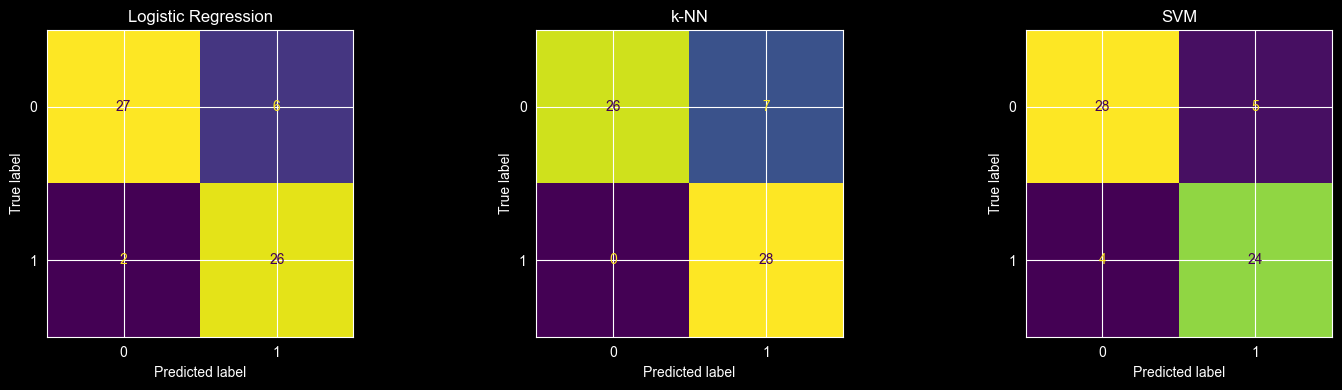

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[1], colorbar=False)
axes[1].set_title('k-NN')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[2], colorbar=False)
axes[2].set_title('SVM')

plt.tight_layout()
plt.show()


## 11. ROC curves

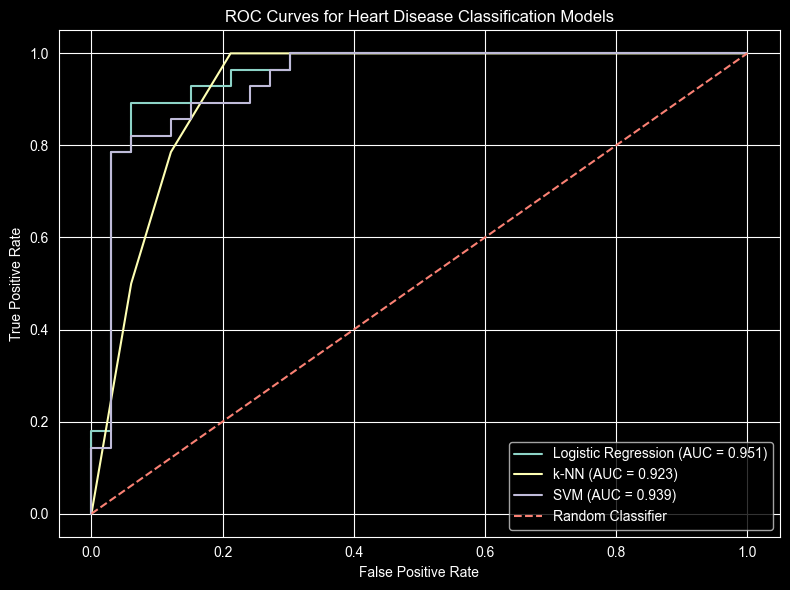

In [11]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_results["ROC-AUC"]:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {knn_results["ROC-AUC"]:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {svm_results["ROC-AUC"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Heart Disease Classification Models')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Metric comparison bar chart

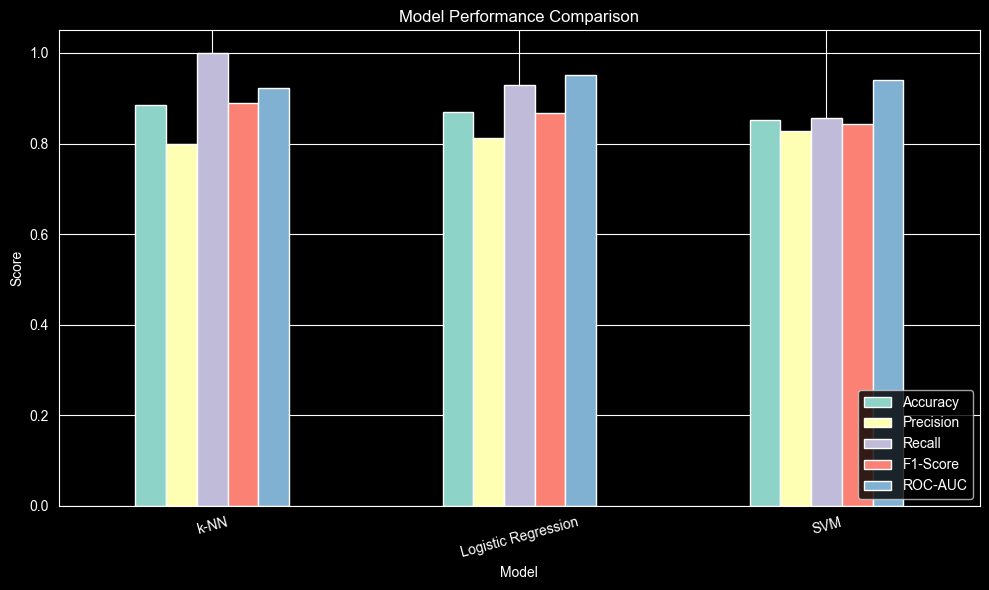

In [12]:
results_plot = results_df.set_index('Model')
results_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 13. PCA explained variance

Explained variance ratio by component:
[0.2459193  0.12255207 0.10055118 0.0877544  0.07372672 0.07014065
 0.06215425 0.05599888 0.05155779 0.042923   0.03277473 0.03039509
 0.02355195]

Cumulative explained variance:
[0.2459193  0.36847137 0.46902255 0.55677695 0.63050366 0.70064431
 0.76279857 0.81879744 0.87035523 0.91327823 0.94605296 0.97644805
 1.        ]


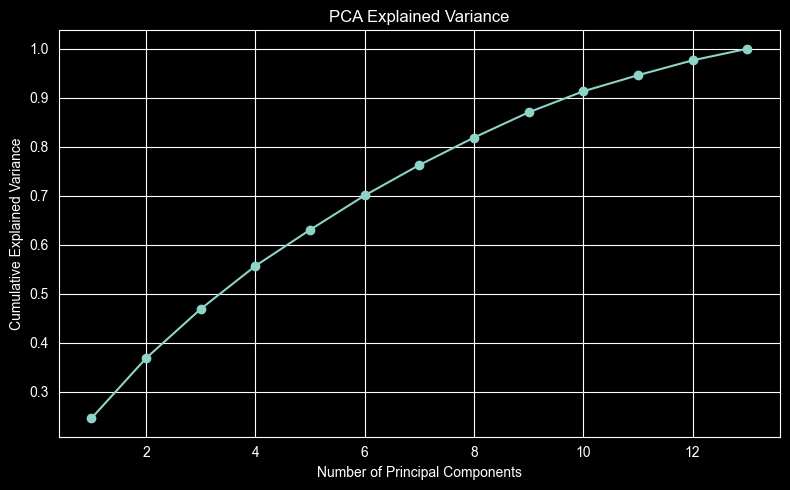

In [13]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_ratio)

print('Explained variance ratio by component:')
print(explained_ratio)
print('\nCumulative explained variance:')
print(cum_var)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()


## 14. PCA scatterplot (2 components for visualization)

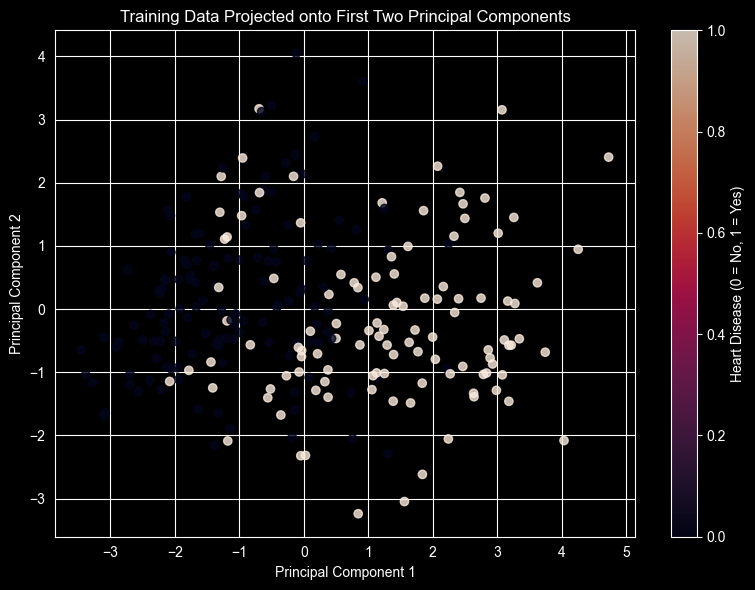

Explained variance ratio (2 components): [0.2459193  0.12255207]
Total explained variance (2 components): 0.3684713661324357


In [14]:
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca2[:, 0],
    X_train_pca2[:, 1],
    c=y_train,
    alpha=0.8,
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Training Data Projected onto First Two Principal Components')
plt.colorbar(label='Heart Disease (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

print('Explained variance ratio (2 components):', pca_2.explained_variance_ratio_)
print('Total explained variance (2 components):', pca_2.explained_variance_ratio_.sum())


## 15. PCA-based models

Choose the smallest number of components that explains at least 90% of the variance.

In [15]:
n_comp = np.argmax(cum_var >= 0.90) + 1
print('Chosen number of components (>=90% variance):', n_comp)

pca = PCA(n_components=n_comp)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Original shape:', X_train_scaled.shape)
print('PCA shape:', X_train_pca.shape)
print('Explained variance retained:', pca.explained_variancse_ratio_.sum())


Chosen number of components (>=90% variance): 10
Original shape: (242, 13)
PCA shape: (242, 10)
Explained variance retained: 0.9132782301145128


### Logistic Regression + PCA

In [16]:
log_reg_pca = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg_pca.fit(X_train_pca, y_train)

y_pred_log_pca = log_reg_pca.predict(X_test_pca)
y_prob_log_pca = log_reg_pca.predict_proba(X_test_pca)[:, 1]

log_pca_results = evaluate_classifier('Logistic Regression + PCA', y_test, y_pred_log_pca, y_prob_log_pca)


Logistic Regression + PCA
-------------------------
Accuracy: 0.8689
Precision: 0.8125
Recall: 0.9286
F1-Score: 0.8667
ROC-AUC: 0.9470

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



### k-NN + PCA

In [17]:
knn_grid_pca = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': list(range(1, 21))},
    cv=5,
    scoring='accuracy'
)
knn_grid_pca.fit(X_train_pca, y_train)

best_k_pca = knn_grid_pca.best_params_['n_neighbors']
print('Best k for PCA data:', best_k_pca)
print('Best CV accuracy:', knn_grid_pca.best_score_)

knn_pca = KNeighborsClassifier(n_neighbors=best_k_pca)
knn_pca.fit(X_train_pca, y_train)

y_pred_knn_pca = knn_pca.predict(X_test_pca)
y_prob_knn_pca = knn_pca.predict_proba(X_test_pca)[:, 1]

knn_pca_results = evaluate_classifier('k-NN + PCA', y_test, y_pred_knn_pca, y_prob_knn_pca)


Best k for PCA data: 4
Best CV accuracy: 0.8305272108843538
k-NN + PCA
----------
Accuracy: 0.7869
Precision: 0.7586
Recall: 0.7857
F1-Score: 0.7719
ROC-AUC: 0.8804

Confusion Matrix:
[[26  7]
 [ 6 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        33
           1       0.76      0.79      0.77        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



### SVM + PCA

In [18]:
svm_grid_pca = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1],
        'kernel': ['rbf']
    },
    cv=5,
    scoring='accuracy'
)
svm_grid_pca.fit(X_train_pca, y_train)

print('Best PCA SVM params:', svm_grid_pca.best_params_)
print('Best CV accuracy:', svm_grid_pca.best_score_)

svm_pca = svm_grid_pca.best_estimator_
svm_pca.fit(X_train_pca, y_train)

y_pred_svm_pca = svm_pca.predict(X_test_pca)
y_prob_svm_pca = svm_pca.predict_proba(X_test_pca)[:, 1]

svm_pca_results = evaluate_classifier('SVM + PCA', y_test, y_pred_svm_pca, y_prob_svm_pca)


Best PCA SVM params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.8427721088435375
SVM + PCA
---------
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-Score: 0.8621
ROC-AUC: 0.9459

Confusion Matrix:
[[28  5]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



## 16. Compare PCA-based models

In [19]:
pca_results_df = pd.DataFrame([log_pca_results, knn_pca_results, svm_pca_results])
pca_results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression + PCA,0.868852,0.812500,0.928571,0.866667,0.946970
1,k-NN + PCA,0.786885,0.758621,0.785714,0.771930,0.880411
2,SVM + PCA,0.868852,0.833333,0.892857,0.862069,0.945887


## 17. Compare original vs PCA models

In [20]:
combined_results_df = pd.concat([
    results_df.assign(Version='Original'),
    pca_results_df.assign(Version='PCA')
], ignore_index=True)

combined_results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Version
0,k-NN,0.885246,0.800000,1.000000,0.888889,0.923160,Original
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299,Original
2,SVM,0.852459,0.827586,0.857143,0.842105,0.939394,Original
3,Logistic Regression + PCA,0.868852,0.812500,0.928571,0.866667,0.946970,PCA
4,k-NN + PCA,0.786885,0.758621,0.785714,0.771930,0.880411,PCA
5,SVM + PCA,0.868852,0.833333,0.892857,0.862069,0.945887,PCA


## 18. Hierarchical clustering exploratory extension

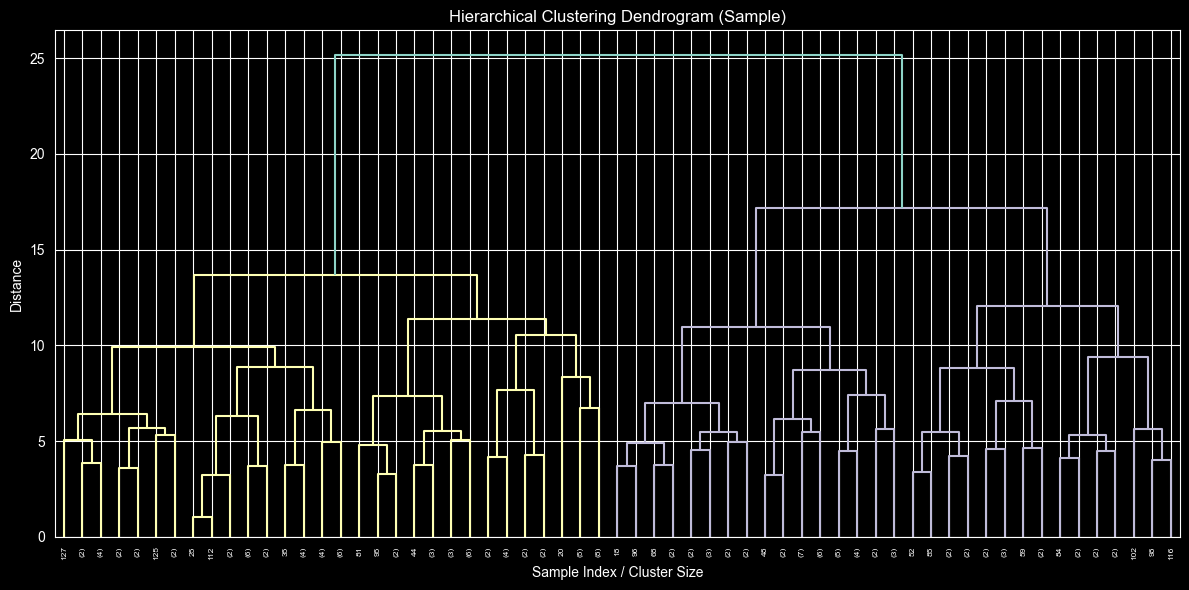

In [21]:
# Scale the full feature matrix for clustering
X_scaled_full = scaler.transform(X)

# Sample for readable dendrogram
sample_n = min(150, X_scaled_full.shape[0])
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    np.arange(X_scaled_full.shape[0]),
    size=sample_n,
    replace=False
)

X_sample = X_scaled_full[sample_idx]
Z_sample = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_sample, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Sample)')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


## 19. Cluster labels and heart disease rates

In [22]:
Z_full = linkage(X_scaled_full, method='ward')
cluster_labels = fcluster(Z_full, t=3, criterion='maxclust')

cluster_df = pd.DataFrame(X, columns=X.columns)
cluster_df['target'] = y.values
cluster_df['cluster'] = cluster_labels

cluster_summary = cluster_df.groupby('cluster').agg(
    n_obs=('target', 'size'),
    heart_disease_rate=('target', 'mean')
)

cluster_summary


,n_obs,heart_disease_rate
cluster,,
1,186,0.306452
2,44,0.500000
3,73,0.821918


## 20. Plot heart disease rate by cluster

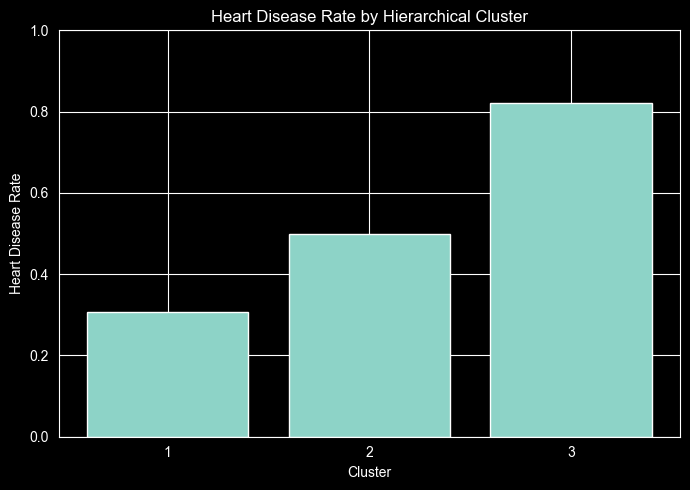

In [23]:
plt.figure(figsize=(7, 5))
plt.bar(cluster_summary.index.astype(str), cluster_summary['heart_disease_rate'])
plt.xlabel('Cluster')
plt.ylabel('Heart Disease Rate')
plt.title('Heart Disease Rate by Hierarchical Cluster')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 21. save result tables

In [24]:
results_df.to_csv('original_model_results.csv', index=False)
pca_results_df.to_csv('pca_model_results.csv', index=False)
combined_results_df.to_csv('all_model_results.csv', index=False)
cluster_summary.to_csv('hierarchical_cluster_summary.csv')

print('Saved:')
print('- original_model_results.csv')
print('- pca_model_results.csv')
print('- all_model_results.csv')
print('- hierarchical_cluster_summary.csv')


Saved:
- original_model_results.csv
- pca_model_results.csv
- all_model_results.csv
- hierarchical_cluster_summary.csv
